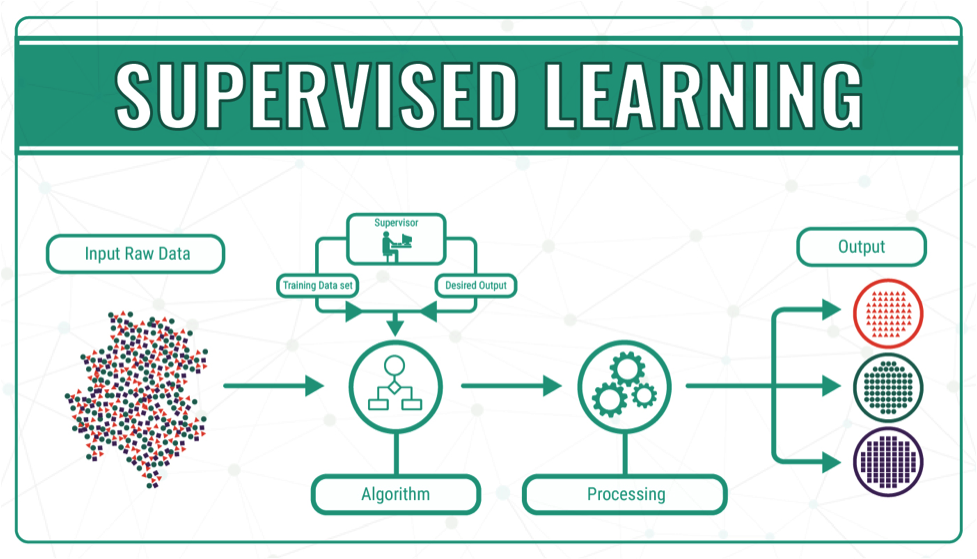


# **Classification**  
Titanic dataset

## **0. Libraries**


In [1]:
#Imports
import numpy as np
import pandas as pd
import operator
from matplotlib import pyplot as plt

## **1. Data load**


#### Opción A => Leer un fichero local de tu ordenador desde Google Colab

In [2]:
#To read files from a Google Colab environment
from google.colab import files
import io

uploaded = files.upload()   #Upload the cleaned.csv from the previous notebook or from the data folder
uploaded

Saving cleaned.csv to cleaned.csv


{'cleaned.csv': b'PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked\n0.0,0.0,1.0,1.0,0.375,0.125,0.0,0.27756871130280647,1.0\n0.0011235955056179776,1.0,0.0,0.0,0.6756529960807622,0.125,0.0,0.8703529470071392,0.0\n0.002247191011235955,1.0,1.0,0.0,0.4583433440995439,0.0,0.0,0.29020249452154734,1.0\n0.0033707865168539327,1.0,0.0,0.0,0.625,0.125,0.0,0.7511882157413031,1.0\n0.0044943820224719105,0.0,1.0,1.0,0.625,0.0,0.0,0.292482203509092,1.0\n0.0056179775280898875,0.0,1.0,1.0,0.49760432934529897,0.0,0.0,0.2998078832345908,0.5\n0.006741573033707865,0.0,0.0,1.0,0.9171660051302553,0.0,0.0,0.742383361338905,1.0\n0.007865168539325843,0.0,1.0,1.0,0.0,0.375,0.16666666666666666,0.4732441971653474,1.0\n0.008988764044943821,1.0,1.0,0.0,0.47815564732237426,0.0,0.3333333333333333,0.34396437296603405,1.0\n0.010112359550561799,1.0,0.5,0.0,0.18148074124883995,0.125,0.0,0.5652935066274886,0.0\n0.011235955056179777,1.0,1.0,0.0,0.0,0.125,0.16666666666666666,0.4212692323746095,1.0\n0.012359550561

#### Opción B => Leer de Drive (se debe aceptar permiso)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/My Drive/Colab Notebooks/

/content/drive/My Drive/Colab Notebooks


In [6]:
PATH_NAME = '/content/cleaned.csv' # Write your path

df = pd.read_csv(PATH_NAME)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.000000,0.0,1.0,1.0,0.375000,0.125,0.0,0.277569,1.0
1,0.001124,1.0,0.0,0.0,0.675653,0.125,0.0,0.870353,0.0
2,0.002247,1.0,1.0,0.0,0.458343,0.000,0.0,0.290202,1.0
3,0.003371,1.0,0.0,0.0,0.625000,0.125,0.0,0.751188,1.0
4,0.004494,0.0,1.0,1.0,0.625000,0.000,0.0,0.292482,1.0


#### Save a copy to original data loaded

In [7]:
df_original = df.copy()

## **1. Models**

Which people could survive for Titanic?

### 1.1.  Define X and y

In [8]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.000000,1.0,1.0,0.375000,0.125,0.0,0.277569,1.0
1,0.001124,0.0,0.0,0.675653,0.125,0.0,0.870353,0.0
2,0.002247,1.0,0.0,0.458343,0.000,0.0,0.290202,1.0
3,0.003371,0.0,0.0,0.625000,0.125,0.0,0.751188,1.0
4,0.004494,1.0,1.0,0.625000,0.000,0.0,0.292482,1.0


We are going to remove PassengerId because it's not a relevant informartion to train the models

In [9]:
X.drop('PassengerId', axis=1, inplace=True)  #with inplace=True we make the changes into the itself dataframe
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,1.0,0.375000,0.125,0.0,0.277569,1.0
1,0.0,0.0,0.675653,0.125,0.0,0.870353,0.0
2,1.0,0.0,0.458343,0.000,0.0,0.290202,1.0
3,0.0,0.0,0.625000,0.125,0.0,0.751188,1.0
4,1.0,1.0,0.625000,0.000,0.0,0.292482,1.0


### 1.2.  Decision trees

#### Train classifier

In [10]:
from sklearn import tree
clf_tr = tree.DecisionTreeClassifier(criterion='entropy')
clf_tr = clf_tr.fit(X, y) # Train the model with X and y

#### Tree Visualization

[Text(0.4278743839605735, 0.9791666666666666, 'Sex <= 0.5\nentropy = 0.961\nsamples = 891\nvalue = [549, 342]'),
 Text(0.16913082437275986, 0.9375, 'Pclass <= 0.75\nentropy = 0.824\nsamples = 314\nvalue = [81.0, 233.0]'),
 Text(0.2985026041666667, 0.9583333333333333, 'True  '),
 Text(0.06093189964157706, 0.8958333333333334, 'Fare <= 0.554\nentropy = 0.299\nsamples = 170\nvalue = [9, 161]'),
 Text(0.04659498207885305, 0.8541666666666666, 'Fare <= 0.548\nentropy = 0.469\nsamples = 70\nvalue = [7, 63]'),
 Text(0.03942652329749104, 0.8125, 'Age <= 0.407\nentropy = 0.426\nsamples = 69\nvalue = [6.0, 63.0]'),
 Text(0.03225806451612903, 0.7708333333333334, 'entropy = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.04659498207885305, 0.7708333333333334, 'Age <= 0.488\nentropy = 0.503\nsamples = 54\nvalue = [6, 48]'),
 Text(0.02867383512544803, 0.7291666666666666, 'Age <= 0.448\nentropy = 0.845\nsamples = 11\nvalue = [3, 8]'),
 Text(0.014336917562724014, 0.6875, 'Fare <= 0.382\nentropy = 0.592\ns

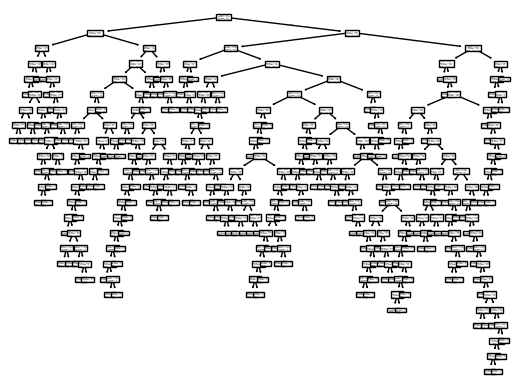

In [11]:
tree.plot_tree(clf_tr, feature_names=X.columns)

In [12]:
df['Survived2'] = df['Survived'].replace({0:'No',1:'Yes'})
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived2
0,0.000000,0.0,1.0,1.0,0.375000,0.125,0.0,0.277569,1.0,No
1,0.001124,1.0,0.0,0.0,0.675653,0.125,0.0,0.870353,0.0,Yes
2,0.002247,1.0,1.0,0.0,0.458343,0.000,0.0,0.290202,1.0,Yes
3,0.003371,1.0,0.0,0.0,0.625000,0.125,0.0,0.751188,1.0,Yes
4,0.004494,0.0,1.0,1.0,0.625000,0.000,0.0,0.292482,1.0,No


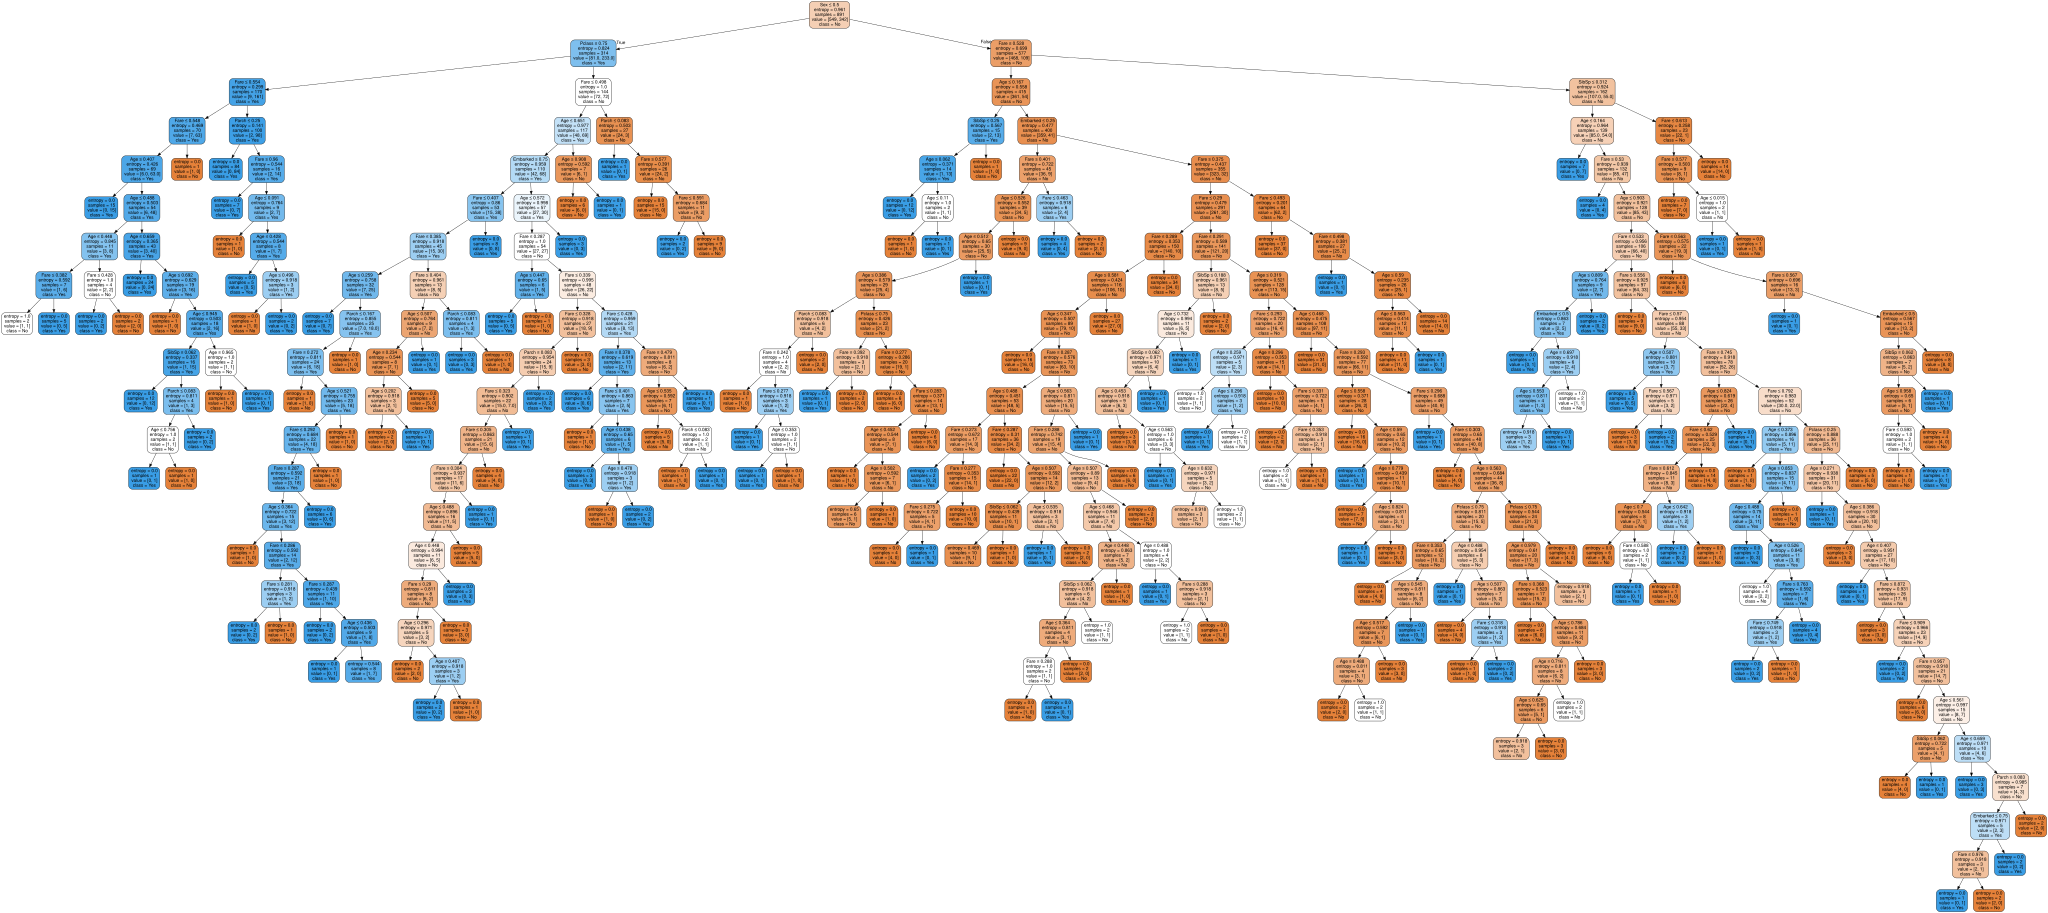

In [13]:
import graphviz

dot_data = tree.export_graphviz(clf_tr, feature_names=X.columns, out_file=None, class_names=df['Survived2'].unique(), filled=True, rounded=True, special_characters=True)

graph = graphviz.Source(dot_data)
graph.render(PATH_NAME, format='png')

graph


Let's go to find the next case in our generated tree

In [14]:
df.loc[0]

,0
PassengerId,0.0
Survived,0.0
Pclass,1.0
Sex,1.0
Age,0.375
SibSp,0.125
Parch,0.0
Fare,0.277569
Embarked,1.0
Survived2,No


### 1.3. Logistic Regression  
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

The logistic regression function can be expresed as::

$$
\text{logit}(p) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n
$$

where:
- ( logit(p) ) is the logit of the probability of the postive class.
- (beta_0 ) is the intercept.
- (beta_1, \beta_2, \beta_n ) are the features' coefficients.
- (X_1, X_2, \ldots, X_n \) are the features' values.



### Example
$$
\text{logit}(p) = -0.5 + 0.03 \cdot \text{Fare} - 1.5 \cdot \text{Sex}
$$

For converting the logit into a probability, the sigmoid function is used:

$$
p = \frac{1}{1 + e^{-\text{logit}(p)}}
$$


**Time to work**  
Import the Logistic Regression Library and train the model with X and y  
Try to print the intercept and coefficients learned for your model

In [18]:
from sklearn.linear_model import LogisticRegression

# Limpiamos X de cualquier columna de texto residual generada previamente
if 'Survived2' in X.columns:
    X = X.drop('Survived2', axis=1)

# Inicializamos el modelo de Regresión Logística
log_reg = LogisticRegression(max_iter=1000)

# Entrenamos el modelo con los datos numéricos limpios
log_reg.fit(X, y)

# Imprimimos el intercepto (la probabilidad base)
print("Intercepto del modelo (Intercept):")
print(f"{log_reg.intercept_[0]:.4f}")
print("=" * 40)

# Imprimimos los coeficientes (el peso que le da a cada columna)
print("Coeficientes aprendidos por el modelo:")
print("-" * 40)

# Creamos una tabla ordenada para ver fácilmente qué variables importan más
coef_df = pd.DataFrame({
    'Característica (Feature)': X.columns,
    'Coeficiente (Weight)': log_reg.coef_[0]
})

# Ordenamos de mayor a menor impacto y lo imprimimos
print(coef_df.sort_values(by='Coeficiente (Weight)', ascending=False).to_string(index=False))

Intercepto del modelo (Intercept):
3.0464
Coeficientes aprendidos por el modelo:
----------------------------------------
Característica (Feature)  Coeficiente (Weight)
                    Fare              0.857955
             PassengerId              0.092743
                Embarked             -0.420286
                   Parch             -0.676868
                     Age             -1.678083
                  Pclass             -1.746350
                   SibSp             -1.835162
                     Sex             -2.552217


## **2. Performance**  
How to compare the 2 models? We need to split data in train/test and measure how well the model predicts in test data

### 2.1. Split data in Train & Test

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=5, shuffle=True)

In [20]:
print('Lenght train: ',len(X_train), ' Lenght test: ', len(X_test))

Lenght train:  712  Lenght test:  179


### 2.2 Train with X_train

In [21]:
# Decision Tree
clf_tr = tree.DecisionTreeClassifier(criterion='entropy')
clf_tr = clf_tr.fit(X_train, y_train)

# Logistic Regression
clf_lr = LogisticRegression(random_state = 0)
clf_lr = clf_lr.fit(X_train, y_train)

### 2.3 Test with X_test


In [22]:
# Decision Tree
y_pred_tr = clf_tr.predict(X_test)
y_pred_tr_prob = clf_tr.predict_proba(X_test)[:, 1]  #probabilities for every prediction

# Logistic Regression
y_pred_lr = clf_lr.predict(X_test)
y_pred_lr_prob = clf_lr.predict_proba(X_test)[:, 1]  #probabilities for every prediction

In [23]:
y_pred_tr

array([0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 0., 1., 0.,
       1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0.,
       1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
       1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0.,
       1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1.,
       1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1.,
       0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1.,
       0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0.,
       0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 1., 1., 0., 1., 0., 1., 0.])

In [24]:
y_pred_tr_prob

array([0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 0., 1., 0.,
       1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0.,
       1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
       1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0.,
       1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1.,
       1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1.,
       0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1.,
       0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0.,
       0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 1., 1., 0., 1., 0., 1., 0.])

In [25]:
y_pred_lr

array([0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0.,
       1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 1., 1., 0.,
       1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0.,
       0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0., 0., 1.,
       1., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1.,
       0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 0., 1.,
       0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 1., 0., 1., 1., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0.,
       1., 0., 1., 1., 0., 0., 0., 1., 0.])

In [26]:
y_pred_lr_prob

array([0.11721233, 0.14543893, 0.08294153, 0.13060269, 0.0920448 ,
       0.25654881, 0.91364004, 0.0955497 , 0.95895597, 0.06942591,
       0.16653083, 0.45700497, 0.12594118, 0.84497535, 0.13399051,
       0.77583648, 0.08860101, 0.60868784, 0.12770304, 0.18953662,
       0.20159818, 0.62411657, 0.89210678, 0.64892979, 0.54060163,
       0.09051084, 0.53078657, 0.3034287 , 0.12941803, 0.27800181,
       0.13576446, 0.62861582, 0.81165123, 0.1253461 , 0.93863504,
       0.49169269, 0.25397781, 0.56071965, 0.11972852, 0.09575148,
       0.07276597, 0.80620064, 0.09330257, 0.20898504, 0.07230086,
       0.10603878, 0.80519061, 0.80941652, 0.41615292, 0.05802418,
       0.44369493, 0.75288799, 0.87666723, 0.11211799, 0.1626434 ,
       0.08102779, 0.28405095, 0.06829981, 0.14836073, 0.75208719,
       0.369194  , 0.3900601 , 0.53010201, 0.13678814, 0.64146938,
       0.1363015 , 0.098412  , 0.16294156, 0.42863746, 0.08622005,
       0.78038911, 0.09999527, 0.79689612, 0.1287715 , 0.66772

We don't have the same results (predictions) in Decision Tree model than in Logistic Regression model.  
Which model is the best? => WE HAVE TO MEASURE COMPARING WITH y_test (the expected result)

### 2.4 Confusion Matrix

Confusion Matrix for Decision Tree  

[[88 23]
 [17 51]]

Confusion Matrix for Decision Tree  



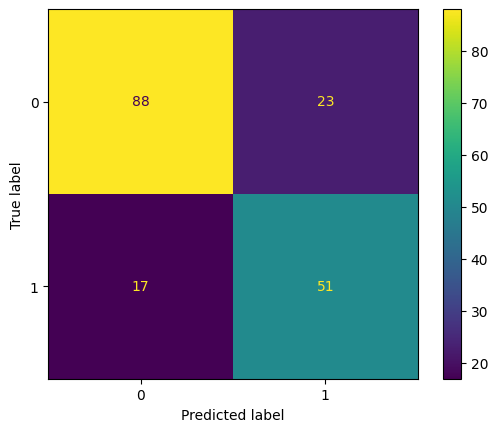

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print('\033[1m' + 'Confusion Matrix for Decision Tree','\033[0m', '\n')
cm_tr = confusion_matrix(y_test, y_pred_tr)
print(cm_tr)

print('\n\033[1m' + 'Confusion Matrix for Decision Tree','\033[0m', '\n')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tr)
disp.plot()

**Time to work**  
Print and plot the confusion matrix for the Logistic Regression

Confusion Matrix for Logistic Regression  



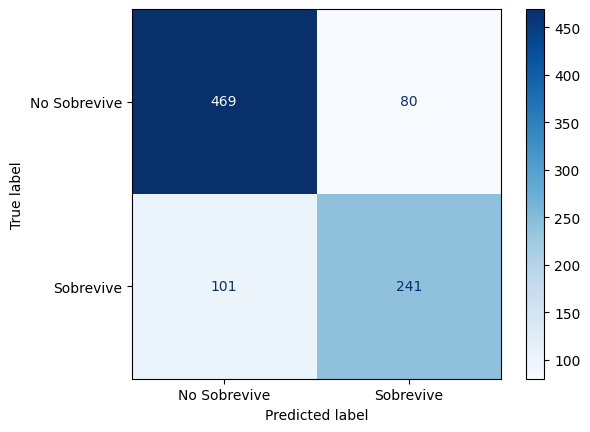

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print('\033[1m' + 'Confusion Matrix for Logistic Regression','\033[0m', '\n')

# Hacemos que la Regresión Logística prediga los resultados
y_pred_log = log_reg.predict(X)

# Calculamos la matriz comparando las predicciones con la realidad (y)
cm_log = confusion_matrix(y, y_pred_log)

# Creamos la visualización
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['No Sobrevive', 'Sobrevive'])
disp_log.plot(cmap='Blues') # Usamos tonos azules para este modelo

plt.show()

Confusion Matrix for Decision Tree  



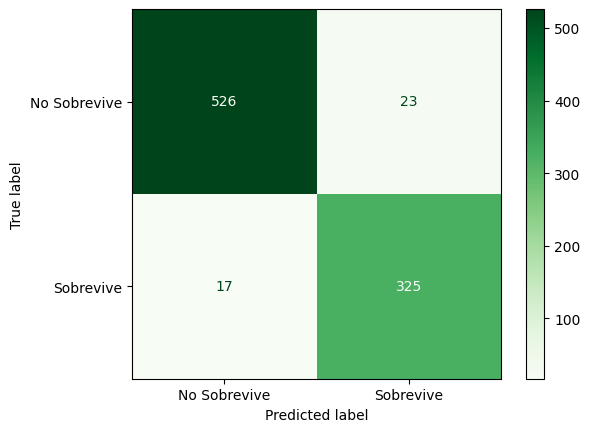

In [29]:
print('\033[1m' + 'Confusion Matrix for Decision Tree','\033[0m', '\n')

# Hacemos que el Árbol de Decisión prediga los resultados
y_pred_tree = clf_tr.predict(X)

# Calculamos la matriz
cm_tree = confusion_matrix(y, y_pred_tree)

# Creamos la visualización
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['No Sobrevive', 'Sobrevive'])
disp_tree.plot(cmap='Greens') # Usamos tonos verdes para diferenciarlo

plt.show()

### 2.5 Accuracy, Recall, Precision, f1-score

**Time to work**  
Measure the Accuracy, Precision, Recall and f1-score from Decision Tree and Logistic Regression models
More info: https://scikit-learn.org/stable/modules/model_evaluation.html


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hacemos las predicciones (por si no se guardaron en la celda anterior)
y_pred_tree = clf_tr.predict(X)

# Calculamos e imprimimos las métricas
print('\033[1m' + 'Metrics for Decision Tree Model' + '\033[0m')
print("-" * 35)
print(f"Accuracy  : {accuracy_score(y, y_pred_tree):.4f}")
print(f"Precision : {precision_score(y, y_pred_tree):.4f}")
print(f"Recall    : {recall_score(y, y_pred_tree):.4f}")
print(f"F1-score  : {f1_score(y, y_pred_tree):.4f}")

Metrics for Decision Tree Model
-----------------------------------
Accuracy  : 0.9551
Precision : 0.9339
Recall    : 0.9503
F1-score  : 0.9420


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hacemos las predicciones
y_pred_log = log_reg.predict(X)

# Calculamos e imprimimos las métricas
print('\033[1m' + 'Metrics for Logistic Regression Model' + '\033[0m')
print("-" * 35)
print(f"Accuracy  : {accuracy_score(y, y_pred_log):.4f}")
print(f"Precision : {precision_score(y, y_pred_log):.4f}")
print(f"Recall    : {recall_score(y, y_pred_log):.4f}")
print(f"F1-score  : {f1_score(y, y_pred_log):.4f}")

Metrics for Logistic Regression Model
-----------------------------------
Accuracy  : 0.7969
Precision : 0.7508
Recall    : 0.7047
F1-score  : 0.7270


### 2.6 ROC Curve & AUC  



**Time to work**
Search and code how make the ROC Curve for Decision Tree and Logistion Regression Models

ROC Curve for Decision Tree Model 



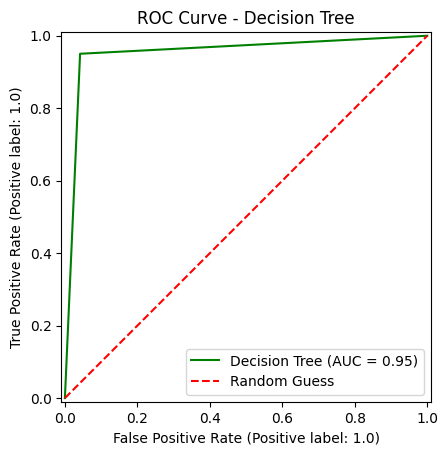

In [32]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

print('\033[1m' + 'ROC Curve for Decision Tree Model' + '\033[0m', '\n')

# Generamos la curva ROC y el AUC directamente desde el modelo entrenado
disp_tree = RocCurveDisplay.from_estimator(clf_tr, X, y, color='green', name='Decision Tree')

# Dibujamos la línea diagonal de referencia (que representa adivinar al azar, AUC = 0.5)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')

# Añadimos título y mostramos el gráfico
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.show()

ROC Curve for Logistic Regression Model 



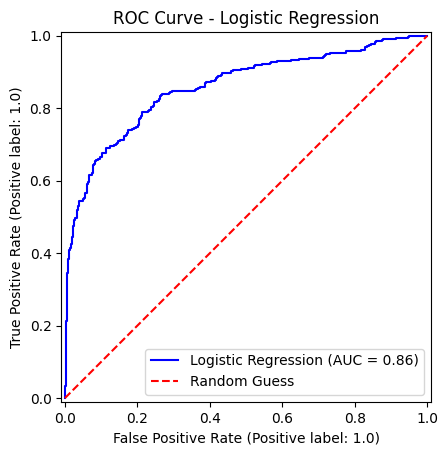

In [33]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

print('\033[1m' + 'ROC Curve for Logistic Regression Model' + '\033[0m', '\n')

# Generamos la curva ROC para la Regresión Logística
disp_log = RocCurveDisplay.from_estimator(log_reg, X, y, color='blue', name='Logistic Regression')

# Dibujamos la línea diagonal de referencia (AUC = 0.5)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')

# Añadimos título y mostramos el gráfico
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

What seems the best model with this Titanic data? Why?

### 2.7 Imbalanced data?

#### Yes or Not

In [34]:
df['Survived2'].value_counts() / len (df)

,count
Survived2,
No,0.616162
Yes,0.383838


#### Balance the classes

This dataset is a litte bit imbalanced. Let's go to balance it.  
We have 3 techniques:  
*   Under sampling
*   Over sampling
*   Generating sinthetic samples (SMOTE)

In [35]:
from sklearn.utils import resample

# concatenate our training data back together
df_xy= pd.concat([X_train, y_train], axis=1)

# Display distribution
print ('\033[1m', 'Before downsampling', '\033[0m')
print(df_xy['Survived'].value_counts() )

df_majority = df_xy[df_xy['Survived']==0]
df_minority = df_xy[df_xy['Survived']==1]

# Downsample majority class
df_majority_downsampled = resample(df_majority,
                                   replace=False,     # sample without replacement
                                   n_samples=len(df_minority),  # to match minority class
                                   random_state=1234) # reproducible results

# Combine minority class with downsampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

# Display new class counts
print ('\n', '\033[1m', 'After downsampling', '\033[0m', )
df_downsampled['Survived'].value_counts()


 Before downsampling 
Survived
0.0    438
1.0    274
Name: count, dtype: int64

  After downsampling 


,count
Survived,
0.0,274
1.0,274


#### Evaluate the new Performance

**Time to work**  
Now we can launch again the fit method to make a new model with the downsampling data and measure if we obtain a better result.  
Have we improved the model?  
Print Confusion Matrix, Accuracy, Recall, Precision, f1-score and ROC Curve with the balanced dataset that we have prepared in the last section

Metrics for Balanced Logistic Regression
---------------------------------------------
Accuracy  : 0.7609
Precision : 0.7658
Recall    : 0.7518
F1-score  : 0.7587

Confusion Matrix & ROC Curve


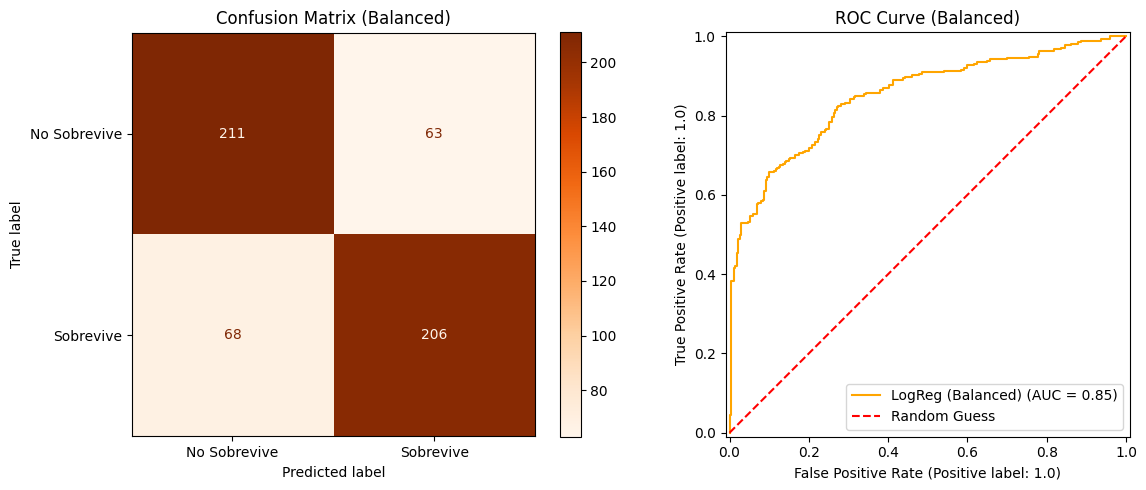

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn import tree  # <-- Importamos el árbol aquí
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)
import matplotlib.pyplot as plt

# Separamos X e y de tu nuevo dataset balanceado
X_down = df_downsampled.drop('Survived', axis=1)
y_down = df_downsampled['Survived']

# =========================================================================
# PREPARAMOS EL ÁRBOL PARA LA SIGUIENTE CELDA
# Entrenamos clf_tr_down para que la celda original que viene después no falle
clf_tr_down = tree.DecisionTreeClassifier(criterion='entropy')
clf_tr_down.fit(X_down, y_down)
# =========================================================================

# Entrenamos el NUEVO modelo de Regresión Logística con los datos balanceados
log_reg_bal = LogisticRegression(max_iter=1000)
log_reg_bal.fit(X_down, y_down)

# Hacemos las predicciones para la Regresión Logística
y_pred_bal = log_reg_bal.predict(X_down)

# Imprimimos las Métricas Numéricas
print('\033[1m' + 'Metrics for Balanced Logistic Regression' + '\033[0m')
print("-" * 45)
print(f"Accuracy  : {accuracy_score(y_down, y_pred_bal):.4f}")
print(f"Precision : {precision_score(y_down, y_pred_bal):.4f}")
print(f"Recall    : {recall_score(y_down, y_pred_bal):.4f}")
print(f"F1-score  : {f1_score(y_down, y_pred_bal):.4f}\n")

# Preparamos las visualizaciones (Matriz de Confusión y Curva ROC)
print('\033[1m' + 'Confusion Matrix & ROC Curve' + '\033[0m')
cm_bal = confusion_matrix(y_down, y_pred_bal)
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=['No Sobrevive', 'Sobrevive'])

# Creamos un lienzo con dos gráficos (1 fila, 2 columnas)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de Confusión
disp_bal.plot(cmap='Oranges', ax=ax[0])
ax[0].set_title('Confusion Matrix (Balanced)')

# Curva ROC
RocCurveDisplay.from_estimator(log_reg_bal, X_down, y_down, color='orange', name='LogReg (Balanced)', ax=ax[1])
ax[1].plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
ax[1].set_title('ROC Curve (Balanced)')
ax[1].legend()

# Ajustamos el espaciado y mostramos todo
plt.tight_layout()
plt.show()

### 2.8 Overfitting/Underfitting?  
Comparing Accuracy between Train / Test and Validation

#### Decision Tree model

In [40]:
y_pred_tr = clf_tr_down.predict(X_train)

print ('\033[1m' + 'Accuracy for Decision Tree in Training phase','\033[0m')
print (f'Accuracy: {accuracy_score(y_train, y_pred_tr):2f}')

print ('\n')
y_pred_tr = clf_tr_down.predict(X_test)
print ('\033[1m' + 'Accuracy for Decision Tree in Testing phase','\033[0m')
print (f'Accuracy: {accuracy_score(y_test, y_pred_tr):2f}' )

Accuracy for Decision Tree in Training phase 
Accuracy: 0.935393


Accuracy for Decision Tree in Testing phase 
Accuracy: 0.743017


Is it balanced? Is it overfitting or underfitting? Why?


#### Logistic Regression model

**Time to work**  
Show the accuracy for both train and testing phase for the Logistic Regression

In [41]:
from sklearn.metrics import accuracy_score

# Fase de Entrenamiento (Training phase)
y_pred_log_train = log_reg_bal.predict(X_train)

print ('\033[1m' + 'Accuracy for Logistic Regression in Training phase','\033[0m')
print (f'Accuracy: {accuracy_score(y_train, y_pred_log_train):2f}')

print ('\n')

# Fase de Pruebas (Testing phase)
y_pred_log_test = log_reg_bal.predict(X_test)

print ('\033[1m' + 'Accuracy for Logistic Regression in Testing phase','\033[0m')
print (f'Accuracy: {accuracy_score(y_test, y_pred_log_test):2f}')

Accuracy for Logistic Regression in Training phase 
Accuracy: 0.772472


Accuracy for Logistic Regression in Testing phase 
Accuracy: 0.815642


The test set may not encompass all the variations present in the training data, but rather only a localized portion of it. This implies that the test set might not be fully representative of the training set, leading to a more favorable evaluation of the model during testing. Essentially, the higher accuracy in the test set could indicate that it does not cover the entire diversity of the training data.